# **Rough differential for volatility**
**Calibration**
---
 
Authors:

    - Antoine Jacquier (a.jacquier@imperial.ac.uk)
    - Ofelia Bonesini
    - Emilio Ferrucci
    - Ioannis Gasteratos
 
Platform: Tested on Windows 10 with Python 3.9

Reference paper: https://arxiv.org/pdf/2412.21192

Date: January 2025

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import jax
import jax.numpy as jnp
import time
from diffrax import *
import pandas as pd
import scipy.signal as signal
import scipy.special as special
from scipy.optimize import minimize
from scipy.optimize import bisect
from scipy.stats import norm
from scipy.stats import multivariate_normal
from concurrent.futures import ProcessPoolExecutor
num_processes = 10  # Adjust based on your machine's CPU cores and task requirements

from controls import *
from hybrid_joint import *
from Jackels import impliedVolJaeckelRational

%matplotlib inline
from scipy import stats
from scipy.stats import norm
import sys

In [2]:
def progressBar(value, endvalue, message = "Running in progress", bar_length=20):
    percent = float(value) / endvalue
    arrow = '-' * int(round(percent * bar_length)-1) + '>'
    spaces = ' ' * (bar_length - len(arrow))
    sys.stdout.write("\r{0}: [{1}] {2}%".format(message,arrow + spaces, int(round(percent * 100))))
    sys.stdout.flush()

### Quadratic RDE Heston model (Section 4.2, Equation (42))

$$
\begin{cases}
\displaystyle \frac{\mathrm{d}S_t}{S_t} = \sqrt{a(Z_t - b)^2 + c\,} \circ \mathrm{d}W_t - \frac{1}{2}\Big(a(Z_t - b)^2 + c\Big) \mathrm{d}t, \\
\displaystyle \mathrm{d}Z_t = \lambda \theta(t)\mathrm{d}t + \lambda \eta \sqrt{a(Z_t - b)^2 + c\,} \circ \mathrm{d} W^H_t,
\end{cases}
$$

with $\theta$ some function chosen to match the VIX futures.
This is the same as solving $V$ first and then taking the exponential martingale

$$
S_t =S_0 \exp\bigg(\int_0^t\sqrt{a(Z_t - b)^2 + c\,} \mathrm{d}W - \frac 12 \int_0^t (a(Z_t - b)^2 + c) \mathrm{d}t \bigg).
$$


Note that this can be equivalently written as

$$
\begin{cases}
\displaystyle \frac{\mathrm{d}S_t}{S_t} & = \displaystyle- \frac{\sigma_t^2}{2}\mathrm{d}t + \sigma_t \circ \mathrm{d}W_t, \\
\displaystyle \mathrm{d}Z_t & = \displaystyle\lambda \theta(t)\mathrm{d}t + \lambda \eta\, \sigma_t \circ \mathrm{d} W^H_t,\\
\displaystyle \sigma_t & = \displaystyle\sqrt{a(Z_t - b)^2 + c}.
\end{cases}
$$

In [3]:
class RDE_QuadHeston:
    """
    RDE Heston class
    """
    
    def __init__(self, nb_grid_points, nbPaths, T, H, S0):
        """
        nb_grid_points: number of points in the simulation grid
        H: Hurst parameter
        nbPaths: number of paths to simulate
        T: maturity
        S0: initial value of the stock price
        """
        self.S0 = S0
        self.epsilon = 1. / nb_grid_points #time step
        self.solver_epsilon = 0.02*self.epsilon # smaller time step
        self.lag = 1.2*self.epsilon # lag (it has to be slightly bigger than the time step)
        self.nb_grid_points = nb_grid_points
        self.nbPaths, self.T, self.H = nbPaths, T, H

        self.kappa = 1 # kappa parameter for the Hybrid scheme
        
        # create the time grid (over the time horizon 1)
        self.times = jnp.arange(0., 1., self.epsilon)
        # every point x in the grid is approximated with the closest lower integer to x*eps
        # needed for the subsampling
        self.every_nth_pt = int(self.nb_grid_points*self.epsilon)
        

    def run__init__(self, timerYesNo = False):
        """
        Run initial computations to simulate the Brownian paths
        to be stored and used later on offline.
        """
        t0 = time.time()

        args = (self.nb_grid_points, self.T, self.kappa)
        num_processes = 8  # adjust based on your machine's CPU cores and task requirements
        
        with ProcessPoolExecutor(max_workers=num_processes) as executor:
            self.futures = [executor.submit(degenerate_fbm_1_bm_1_bm_wrapper, args) for _ in range(self.nbPaths)]
            self.results = [future.result() for future in self.futures]

        self.list_fbm, self.list_bm1, self.list_bm2 = zip(*self.results)

        self.stacked_fbm = jnp.stack(self.list_fbm).T
        self.stacked_bm1 = jnp.stack(self.list_bm1).T
        self.stacked_bm2 = jnp.stack(self.list_bm2).T
        
        self.bm1_interp = LinearInterpolation(self.times, self.stacked_bm1)
        self.bm2_interp = LinearInterpolation(self.times, self.stacked_bm2)
        self.fbm_interp = LinearInterpolation(self.times, self.stacked_fbm)

        self.bm1_control = evaluate_and_reshape(self.bm1_interp.evaluate)
        self.bm2_control = evaluate_and_reshape(self.bm2_interp.evaluate)
        self.fbm_control = evaluate_and_reshape(self.fbm_interp.evaluate)
        
        self.fbm_fun = lambda t: self.fbm_interp.evaluate(0,t)
        self.fbm_lagged_control_temp = lagged_control(self.fbm_fun, self.lag)
        self.fbm_lagged_control = lambda s,t: self.fbm_lagged_control_temp(s,t).reshape(1, self.nbPaths)
        
        self.bm_control = stack_controls(self.bm1_control, self.bm2_control)
        self.lead_lag_control = stack_controls(self.fbm_lagged_control, self.bm_control)

        if timerYesNo:
            init_time = time.time() - t0
            print("Initialisation time (Simulating the Brownian paths): ", np.round(init_time, 3), "seconds")

    
    def run_paths_RDE_QuadHeston(self, params):
        """
        Simulate paths for the RDE Heston model
        
        params: paramters of the RDE Heston model
        """
        a, b, c, theta, lam, eta, y0 = params

        saveat = SaveAt(ts = self.times)

        y0_vec = jnp.array([1., y0])
        
        sqrtfunc = lambda y: jnp.sqrt(a * jnp.square(y[1] - b) + c)
        
        drift = lambda t, y, args: jnp.array([-(1/2) * y[0]*sqrtfunc(y)**2, lam * (theta - y[1])])
        diffusion = lambda t, y, args: jnp.array([[0, 0, y[0]*sqrtfunc(y)],[lam * eta * sqrtfunc(y), 0, 0]])
        
        self.rde_paths = vmap_batch_fbm_solve(jnp.arange(self.nbPaths), self.lead_lag_control, drift, diffusion, y0_vec, Midpoint(), 0, 1, self.solver_epsilon, saveat)
        

    def callPrice_RDE_QuadHeston_MC_givenPaths(self, strikes):
        """
        Compute Call option prices given pre-computed (offline) Monte Carlo paths for the stock price
        params: parameters of the model
        strikes: strikes of the Call option prices
        """
        
        # compute integral price and expo martingale for the traj
        exp_martingale_T = self.rde_paths.ys[:, -1, 0]
        times = self.rde_paths.ts[0,:] 
        self.callPrices = [jnp.mean(jnp.maximum(self.S0*exp_martingale_T - K, 0.)) for K in strikes]

    
    def callPrice_RDE_QuadHeston_MC(self, params, strikes):
        """
        Compute Call option prices.
        It first has to generate all the Monte Carlo paths for the stock price 
        (hence much slower than 'callPrice_RDE_QuadHeston_MC_givenPaths()')
        
        params: parameters of the model
        strikes: strikes of the Call option prices
        """
        
        # compute integral price and expo martingale for the traj
        self.run_paths_RDE_QuadHeston(params)
        
        exp_martingale_T = self.rde_paths.ys[:, -1, 0]
        times = self.rde_paths.ts[0,:] 

        self.callPrices = [jnp.mean(jnp.maximum(self.S0*exp_martingale_T - K, 0.)) for K in strikes]
            

    def implied_vol(self, params, strikes):
        """
        Compute the implied volatility
        
        params: parameters of the model
        strikes: strikes of the Call option prices
        """
        
        self.callPrice_RDE_QuadHeston_MC(params, strikes)
        return [impliedVolJaeckelRational(self.S0, K, c, self.T) for (K,c) in zip(strikes, self.callPrices)]
    
    def implied_vol_givenCalls(self, strikes):
        """
        Compute the implied volatility given pre-computed Call option prices
        
        params: parameters of the model
        strikes: strikes of the Call option prices
        """
        
        self.impliedVols = [impliedVolJaeckelRational(self.S0, K, c, self.T) for (K,c) in zip(strikes, self.callPrices)]

## Numerical tests

In [4]:
H = 0.01  ## Hurst parameter
T = 1.  ## Time horizon
S0 = 179.83 ## Initial stock price

### a, b, c, theta, lam, eta, y0 = params ###
params = 0.384, 0.1, 0.01, 0., 1.2, 0.3, 0.1

In [5]:
nb_grid_points = 1000
nbPaths = 20

In [6]:
#############################
## Create an instance of the RDE class and pre-compute all the Brownian paths
rde = RDE_QuadHeston(nb_grid_points, nbPaths, T, H, S0)
rde.run__init__(timerYesNo=True)
#############################

#############################
## Compute the SDE paths
t0 = time.time()
rde.run_paths_RDE_QuadHeston(params)
pricing_time = time.time() - t0
print("SDE simulation computation time: ", np.round(pricing_time, 3), "seconds")
#############################

Initialisation time (Simulating the Brownian paths):  4.037 seconds
SDE simulation computation time:  3.261 seconds


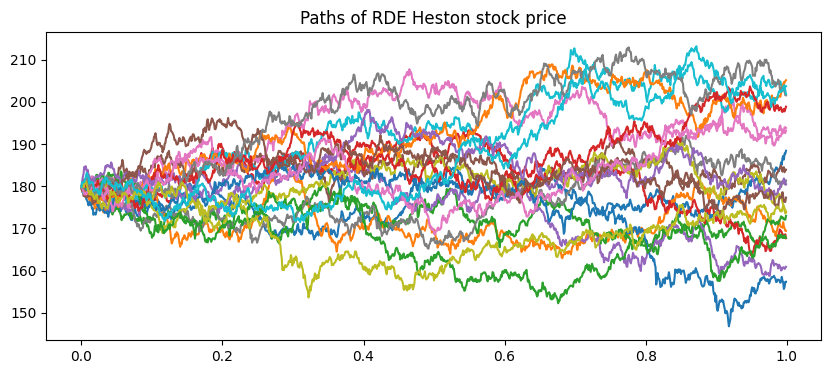

In [7]:
plt.figure(figsize=(10, 4))
for path in range(nbPaths):
    plt.plot(rde.times, S0*rde.rde_paths.ys[path,:,0])
plt.title("Paths of RDE Heston stock price")
plt.show()

## Run Monte Carlo computations for option prices

In [8]:
nb_grid_points = 50
nbPaths = 10000
#############################
## Create an instance of the RDE class and pre-compute all the Brownian paths
rde = RDE_QuadHeston(nb_grid_points, nbPaths, T, H, S0)
rde.run__init__(timerYesNo=True)
#############################

#############################
## Compute the SDE paths
t0 = time.time()
rde.run_paths_RDE_QuadHeston(params)
pricing_time = time.time() - t0
print("SDE simulation computation time: ", pricing_time, "seconds")
#############################

Initialisation time (Simulating the Brownian paths):  17.66 seconds
SDE simulation computation time:  6.312091827392578 seconds


In [9]:
nbStrikes = 30
strikes = np.linspace(S0*np.exp(-0.25), S0*np.exp(0.25), nbStrikes)
log_moneyness = np.log(strikes/S0)

In [10]:
#############################
t0 = time.time()
rde.callPrice_RDE_QuadHeston_MC_givenPaths(strikes)
dtCalls = time.time() - t0
print("Computation time: ", dtCalls, "seconds")
#############################

Computation time:  0.5891356468200684 seconds


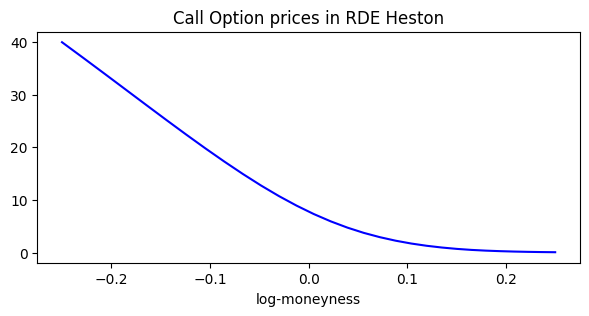

In [11]:
plt.figure(figsize=(7,3))
plt.plot(log_moneyness, rde.callPrices, 'b')
plt.xlabel('log-moneyness')
plt.title('Call Option prices in RDE Heston')
plt.show()

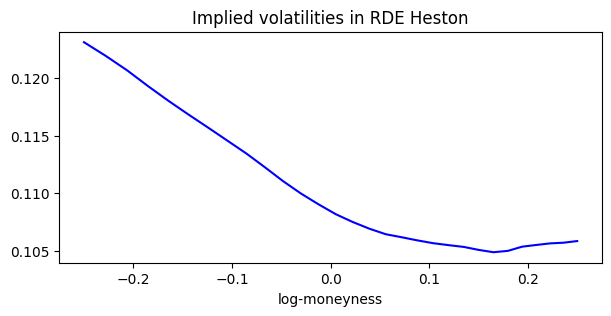

In [12]:
rde.implied_vol_givenCalls(strikes)
plt.figure(figsize=(7,3))
plt.plot(log_moneyness, rde.impliedVols, 'b')
plt.xlabel('log-moneyness')
plt.title('Implied volatilities in RDE Heston')
plt.show()

## Import option price data
We consider one day in history and a given European Call option maturity slice on the S&P500.

In [15]:
r,q = 0.,0. ## assuming no interest rates and no dividends
S0 = 179.83
T = 0.547945205

In [16]:
logStrikes = [-0.63813507, -0.58684177, -0.53805161, -0.49153159, -0.44707983,
       -0.40452022, -0.36369822, -0.32447751, -0.28673718, -0.25036954,
       -0.21527822, -0.18137667, -0.14858684, -0.11683814, -0.08606649,
       -0.05621352, -0.02722599,  0.00094489,  0.02834386,  0.05501211,
        0.0809876 ,  0.10630541,  0.13099802,  0.15509557,  0.17862607,
        0.20161559,  0.22408844,  0.24606735,  0.26757355,  0.28862696,
        0.30924625,  0.32944896,  0.34925158,  0.36866967,  0.38771787,
        0.40641   ,  0.42475914,  0.44277764,  0.46047722,  0.47786896,
        0.4949634 ]

strikes = S0*np.exp(logStrikes)

In [17]:
call_midprices_data = [8.5125e+01, 8.0225e+01, 7.5350e+01, 7.0625e+01, 6.5675e+01,
       6.1150e+01, 5.6275e+01, 5.1525e+01, 4.6975e+01, 4.2550e+01,
       3.8475e+01, 3.4075e+01, 2.9400e+01, 2.5750e+01, 2.1850e+01,
       1.8700e+01, 1.5750e+01, 1.2825e+01, 1.0350e+01, 8.0250e+00,
       6.2500e+00, 4.7500e+00, 3.5250e+00, 2.5300e+00, 1.7450e+00,
       1.3400e+00, 9.4000e-01, 6.7000e-01, 4.8000e-01, 3.6500e-01,
       2.7500e-01, 2.2000e-01, 1.7000e-01, 1.3000e-01, 1.0500e-01,
       8.5000e-02, 7.5000e-02, 6.5000e-02, 6.0000e-02, 5.5000e-02,
       5.5000e-02]

In [18]:
implied_vols_data = [0.41967217, 0.40775452, 0.39583126, 0.39637445, 0.37027343,
       0.37585034, 0.3524786 , 0.33545782, 0.32576207, 0.31722606,
       0.3161998 , 0.30012357, 0.2741788 , 0.27172822, 0.25830136,
       0.25613171, 0.25222195, 0.24331056, 0.23735461, 0.22841143,
       0.22415666, 0.21960631, 0.21514118, 0.21020377, 0.20480333,
       0.20704344, 0.20494064, 0.20436537, 0.20444079, 0.20687493,
       0.2088935 , 0.21270743, 0.21521868, 0.21729165, 0.22074084,
       0.22403286, 0.22935428, 0.23394136, 0.23991287, 0.24546431,
       0.25308132]

In [19]:
liquidity_threshold = 10
logStrikes = logStrikes[liquidity_threshold:]
strikes = strikes[liquidity_threshold:]
call_midprices_data = call_midprices_data[liquidity_threshold:]
implied_vols_data = implied_vols_data[liquidity_threshold:]

Maturity:  0.547945205


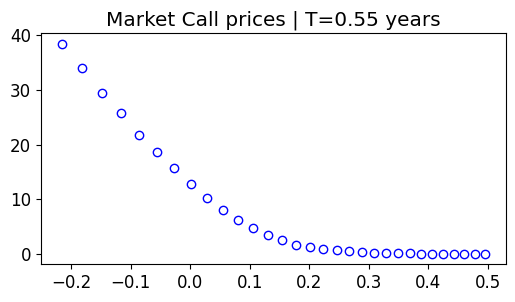

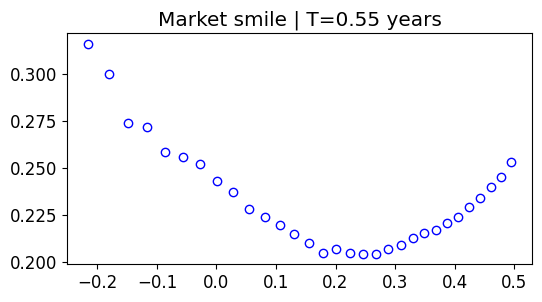

In [33]:
print("Maturity: ", T)

plt.rcParams.update({'font.size': 12})

plt.figure(figsize=(6,3))
plt.plot(logStrikes, call_midprices_data, "bo", mfc="None")
plt.title("Market Call prices | T=" + str(np.round(T, 2)) + " years")
plt.show()

plt.figure(figsize=(6,3))
plt.plot(logStrikes, implied_vols_data, "bo", mfc="None")
plt.title("Market smile | T=" + str(np.round(T, 2)) + " years")
plt.show()

### Calibration on Call prices or on implied volatilities (fixed H)

#### Definition of the loss functions for the calibration

In [21]:
def lossFunction_prices_fixedH_fixedrde(params, rde, strikes, call_prices_data, weights_YesNo = False, dispPrint=False):
    """
    Loss function: L2 error on the option prices
    Note that the RDE has been fixed, namely its Brownian paths have been generated already

    params: parameters of the model
    rde: RDE class instance
    strikes: list of strikes
    ivs_market: implied volatility data
    weights: specify whether the errors should be weighted (Vega weights for example)
    dispPrint: print or not the parameters and errors
    """    

    rde.run_paths_RDE_QuadHeston(params)
    rde.callPrice_RDE_QuadHeston_MC_givenPaths(strikes)
    
    if weights_YesNo: ## calibration with weights. We use a proxy for the Vega
        weights = [np.exp(np.log(rde.S0 / strike)**2) for strike in strikes] ## Examples of weights
        normError = np.sum([w*((a-b)/rde.S0)**2 for (w,a,b) in zip(weights, rde.callPrices, call_prices_data)])
        
    else: ## Compute the L2 errors on the Call prices
        normError = np.sum([(a-b)**2 for (a,b) in zip(rde.callPrices, call_prices_data)])
    
    if dispPrint: ## Printing details
        if weights_YesNo:
            print("Parameters: ", [np.round(p, 5) for p in params], " || L2 error: ", np.round(normError, 5), " ||", weights)
        else:
            print("Parameters: ", [np.round(p, 5) for p in params], " || L2 error: ", np.round(normError, 5))

    return normError


### Initial randomisation, with H fixed

In [22]:
H = 0.02
nbPaths = 10000
nb_grid_points = 40

In [23]:
rde = RDE_QuadHeston(nb_grid_points, nbPaths, T, H, S0)
rde.run__init__(timerYesNo=True)

Initialisation time (Simulating the Brownian paths):  15.788 seconds


In [24]:
initial_params = [0.3152, 0.3044, 0.0146, 0.2468, 1.0, 0.9102, 0.0025]
print("Initial guesses set of parameters: ", initial_params)
print("L2 Error on prices: ", lossFunction_prices_fixedH_fixedrde(initial_params, rde, strikes, call_midprices_data, dispPrint=False))

Initial guesses set of parameters:  [0.3152, 0.3044, 0.0146, 0.2468, 1.0, 0.9102, 0.0025]
L2 Error on prices:  18.052496


In [25]:
## Calibration bound domain. Note that lambda is frozen to 1
calibBounds_noH = ((0.0001,1.), (0.0001,.7), (0.0001,.5), (0.001,0.6), (1., 1.), (0.001,1.2), (0.0001,0.7))

## Calibration on option prices
optim = minimize(lossFunction_prices_fixedH_fixedrde, initial_params, args=(rde, strikes, call_midprices_data, False, True), method='L-BFGS-B', bounds=calibBounds_noH, tol=1E-10, options={'ftol':1E-10})
optimal_param_noH = optim.x
print("Calibration on Call options completed")

Parameters:  [0.3152, 0.3044, 0.0146, 0.2468, 1.0, 0.9102, 0.0025]  || L2 error:  18.0525
Parameters:  [0.3152, 0.3044, 0.0146, 0.2468, 1.0, 0.9102, 0.0025]  || L2 error:  18.0525
Parameters:  [0.3152, 0.3044, 0.0146, 0.2468, 1.0, 0.9102, 0.0025]  || L2 error:  18.0525
Parameters:  [0.3152, 0.3044, 0.0146, 0.2468, 1.0, 0.9102, 0.0025]  || L2 error:  18.05246
Parameters:  [0.3152, 0.3044, 0.0146, 0.2468, 1.0, 0.9102, 0.0025]  || L2 error:  18.0525
Parameters:  [0.3152, 0.3044, 0.0146, 0.2468, 1.0, 0.9102, 0.0025]  || L2 error:  18.0525
Parameters:  [0.3152, 0.3044, 0.0146, 0.2468, 1.0, 0.9102, 0.0025]  || L2 error:  18.05248
Parameters:  [0.3152, 0.3044, 0.5, 0.2468, 1.0, 0.9102, 0.7]  || L2 error:  1794.5035
Parameters:  [0.3152, 0.3044, 0.5, 0.2468, 1.0, 0.9102, 0.7]  || L2 error:  1794.5035
Parameters:  [0.3152, 0.3044, 0.5, 0.2468, 1.0, 0.9102, 0.7]  || L2 error:  1794.5035
Parameters:  [0.3152, 0.3044, 0.5, 0.2468, 1.0, 0.9102, 0.7]  || L2 error:  1794.5035
Parameters:  [0.3152, 0.

In [26]:
print("Initial parameters: ", [np.round(p, 4) for p in initial_params], "loss: ", lossFunction_prices_fixedH_fixedrde(initial_params, rde, strikes, call_midprices_data, True, False))
print("Optimal parameters: ", [np.round(p, 4) for p in optimal_param_noH], "loss: ", lossFunction_prices_fixedH_fixedrde(optimal_param_noH, rde, strikes, call_midprices_data, True, False))

Initial parameters:  [0.3152, 0.3044, 0.0146, 0.2468, 1.0, 0.9102, 0.0025] loss:  0.0005715788
Optimal parameters:  [0.3152, 0.3044, 0.0233, 0.2468, 1.0, 0.9102, 0.023] loss:  0.00027400538


In [27]:
rde.callPrice_RDE_QuadHeston_MC(optimal_param_noH, strikes)

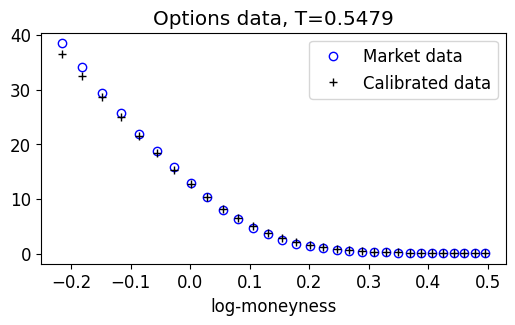

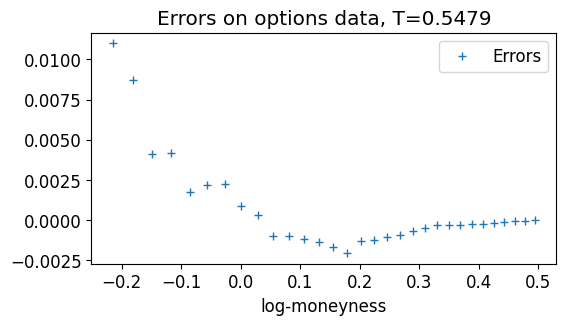

In [32]:
plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(6,3))
plt.plot(logStrikes, call_midprices_data, 'bo', mfc="None", label="Market data")
plt.plot(logStrikes, rde.callPrices, 'k+', label="Calibrated data")
plt.xlabel("log-moneyness")
plt.legend(loc="best")
plt.title("Options data, T=%.4f" %rde.T)
plt.show()

plt.figure(figsize=(6,3))
plt.plot(logStrikes, [(price_data - float(rdeprice)) / S0 for (price_data, rdeprice) in zip(call_midprices_data, rde.callPrices)]
, '+', mfc="None", label="Errors")
plt.xlabel("log-moneyness")
plt.legend(loc="best")
plt.title("Errors on options data, T=%.4f" %rde.T)
plt.show()